## MARBL diagnostics, compare timeseries of global metrics between multiple cases (only 2-d variables)


In [1]:
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import os
from glob import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cftime
import pandas as pd
import matplotlib.gridspec as gridspec
from xgcm import Grid
xr.set_options(keep_attrs=True);

### Come up with short names for each case

In [2]:
short_names = ['003','004'
              ]

### Define number of years and number of cases

In [3]:
num_cases = len(short_names)
num_years = 86 #max years in any of the runs

### Define cases

In [4]:
sandbox = 'g.e30_a09e.GW1850MARBL_CPLHIST_PHYS_CYCLE.ne30pg3_t233_wg37'

case_nums = ['003','004']

user = 'klindsay'

### Define the year range

In [5]:
start_yr = 1
endyr = start_yr + num_years 

### 2-D variable list

In [6]:
variables2d = ['photoC_TOT_zint','photoC_sp_zint','photoC_diat_zint',
               'photoC_diaz_zint','photoC_cocco_zint','CaCO3_PROD_zint',
               'POC_FLUX_100m','x_graze_microzoo_zint',
               'x_graze_mesozoo_zint','IFRAC','FG_CO2','diat_Fe_lim_surf'] 

coords = {'x':'yh','y':'xh'}


keepthese=['z_l','z_i','time_bounds','time','average_T1', 'average_T2','average_DT'] + variables2d + list(coords.values())

### Get dask going

In [7]:
def get_ClusterClient():
    import dask
    from dask_jobqueue import PBSCluster
    from dask.distributed import Client
    cluster = PBSCluster(
        cores=2,
        memory='25 GB',
        processes=1,
        queue='casper',
        resource_spec='select=1:ncpus=1:mem=25GB',
        project='NCGD0011',
        walltime='03:00:00',
        interface='ext',
        log_directory='./dask-logs')

    dask.config.set({
        'distributed.dashboard.link':
        'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'
    })
    client = Client(cluster)
    return cluster, client

In [8]:
cluster, client = get_ClusterClient()
cluster.scale(12) 
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kristenk/proxy/41803/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kristenk/proxy/41803/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.174:43343,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kristenk/proxy/41803/status,Total threads: 0
Started: Just now,Total memory: 0 B


### Read in all the data

In [9]:
cases_dict = {}

for case_num in case_nums:
    case = sandbox + '.' + case_num
    print(case)
    files = []
    for year in range(start_yr,endyr):
        yr4="{:04d}".format(year)
        #print('doing simulation year', year, '!')
        
        files.extend(sorted(glob(f'/glade/derecho/scratch/{user}/archive/{case}/ocn/hist/{case}.mom6.h.bgc.native_annual.{yr4}.nc')))
    ds_tmp = xr.open_mfdataset(files,decode_times=True,decode_coords=False, concat_dim='time',combine='nested' )
    ### drop unnecessary variables
    ds_tmp = ds_tmp.drop([v for v in ds_tmp.variables if v not in keepthese])
    ### resample to annual means
    cases_dict[case_num] = ds_tmp #.resample({'time':'A'}).mean(dim='time', keep_attrs=True).compute()

g.e30_a09e.GW1850MARBL_CPLHIST_PHYS_CYCLE.ne30pg3_t233_wg37.003
g.e30_a09e.GW1850MARBL_CPLHIST_PHYS_CYCLE.ne30pg3_t233_wg37.004


In [10]:
cases_dict.keys()

dict_keys(['003', '004'])

## Get the grid data for MOM6

In [11]:
ds_grid = xr.open_dataset(f'/glade/work/kristenk/cesm_work/mom6_static_files/g.e23b16.TL319_t232.GIAFMARBL.001.mom6.h.static.nc')

In [12]:
lons = ds_grid.geolon
lats = ds_grid.geolat
area = ds_grid.areacello #m2

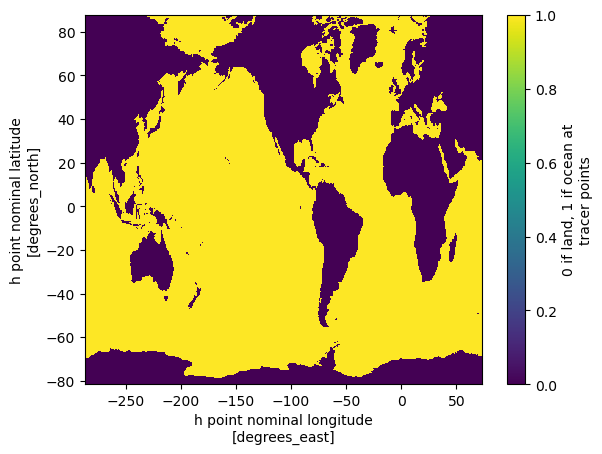

In [13]:
ds_grid.wet.plot()

In [14]:
mmols_to_PgCyr = 1e-3 * 12. * 1e-15 * 365. * 86400.

variables = [f'photoC_{phyto}_zint' for phyto in ['diat', 'sp', 'diaz', 'cocco', 'TOT']]
variables = variables + ['CaCO3_PROD_zint','POC_FLUX_100m','FG_CO2']
variables = variables + [f'x_graze_{zoo}_zint' for zoo in ['microzoo', 'mesozoo']]


glb_ds_dict = {}

for case_num in case_nums:
    
    case = sandbox + '.' + case_num

    ds_glb = xr.Dataset()

    ds = cases_dict[case_num]
    
    for v in variables:
        ds_glb[v] = ((ds[v] * area).sum(dim=('xh', 'yh'))).compute() #mmol/m
        ds_glb[v].attrs = ds[v].attrs
    
        ds_glb[v] = ds_glb[v] * mmols_to_PgCyr        
        ds_glb[v].attrs['units'] = 'Pg C yr$^{-1}$'
    
    
    ######### diatom and zooplankton percents of total NPP
    ds_glb['diatNPPpercent'] = ds_glb.photoC_diat_zint / ds_glb.photoC_TOT_zint * 100.
    ds_glb['diatNPPpercent'].attrs['units'] = '%'
    
    ds_glb['zooprodNPPpercent'] = (ds_glb['x_graze_mesozoo_zint'] + ds_glb['x_graze_microzoo_zint'])/ds_glb['photoC_TOT_zint'] * 100.
    ds_glb['zooprodNPPpercent'].attrs['units'] = '%'
    
    ds_glb = ds_glb.compute()

    glb_ds_dict[case_num] = ds_glb

In [15]:
glb_ds_dict.keys()

dict_keys(['003', '004'])

### Make some timeseries plots for global BGC metrics

In [16]:
st_yr = 37

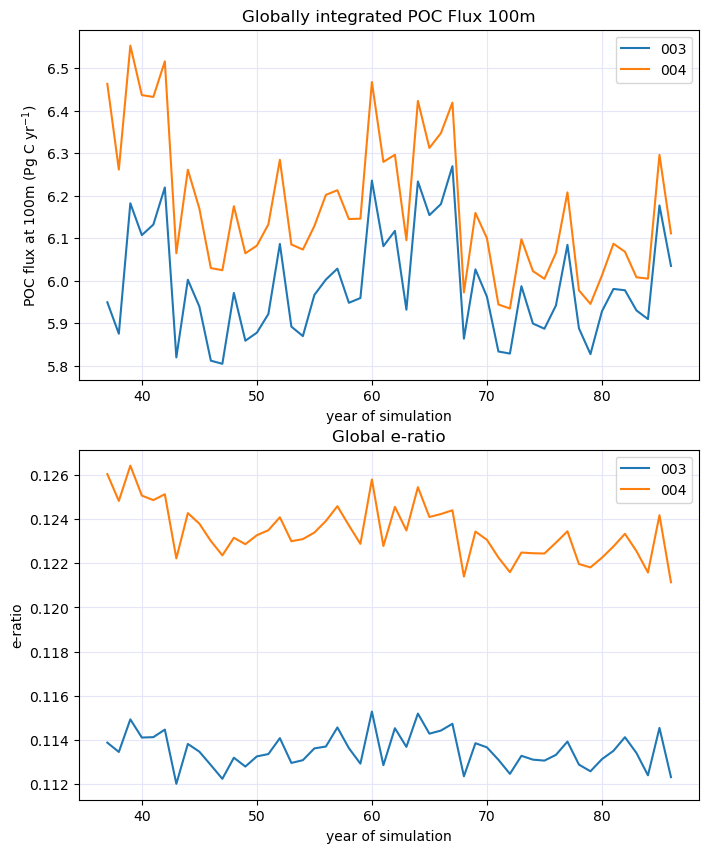

In [17]:
fig = plt.figure(figsize=(8,10))

####################
ax = fig.add_subplot(2,1,1)
ax.set_title('Globally integrated POC Flux 100m')

i = 0

for case_num in case_nums:
    years = np.arange(st_yr,st_yr+len(glb_ds_dict[case_num].time),1)
    ax.plot(years,glb_ds_dict[case_num]['POC_FLUX_100m'],label=short_names[i])
    i = i + 1

# ##################### mark where I tuned 
# var='POC_FLUX_100m'
# year_tune=15
# ax.scatter(year_tune,(glb_ds_dict[case_num][var]).isel(time=year_tune-1),s=20,
#            marker='o',color='red',edgecolor='black', label='Tuning change')


ax.xaxis.grid(True, which='major',color='lavender')
ax.yaxis.grid(False, which='major',color='lavender');

ax.legend()
ax.set(ylabel='POC flux at 100m (Pg C yr$^{-1}$)',xlabel='year of simulation');

######################
ax = fig.add_subplot(2,1,2)
ax.set_title('Global e-ratio')

i = 0

for case_num in case_nums:
    years = np.arange(st_yr,st_yr+len(glb_ds_dict[case_num].time),1)
    ax.plot(years,glb_ds_dict[case_num]['POC_FLUX_100m']/glb_ds_dict[case_num]['photoC_TOT_zint'],label=short_names[i])
    i = i + 1
    
# ############### mark where I tuned
# var='POC_FLUX_100m'
# year_tune=15
# ax.scatter(year_tune,(glb_ds_dict[case_num][var]).isel(time=year_tune-1)/(glb_ds_dict[case_num]['photoC_TOT_zint']).isel(time=year_tune-1),s=20,
#            marker='o',color='red',edgecolor='black', label='Tuning change')

ax.xaxis.grid(True, which='major',color='lavender')
ax.yaxis.grid(False, which='major',color='lavender');

ax.legend()
ax.set(ylabel='e-ratio',xlabel='year of simulation');

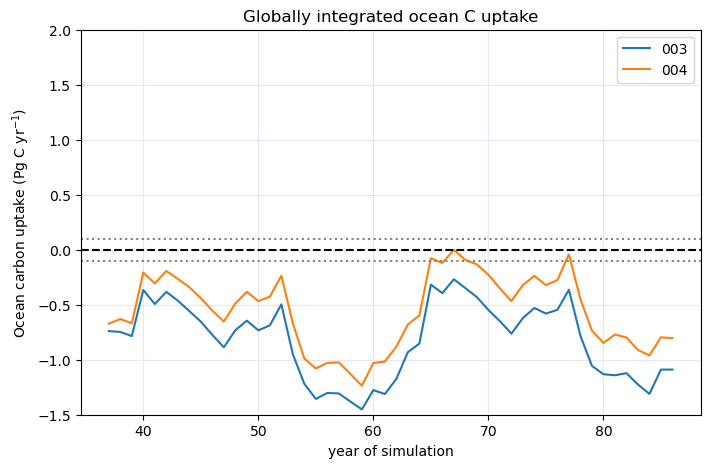

In [18]:
fig = plt.figure(figsize=(8,5))

####################
ax = fig.add_subplot(1,1,1)
ax.set_title('Globally integrated ocean C uptake')

i = 0

for case_num in case_nums:
    years = np.arange(st_yr,st_yr+len(glb_ds_dict[case_num].time),1)
    ax.plot(years,glb_ds_dict[case_num]['FG_CO2'],label=short_names[i])
    i = i + 1

# ##################### mark where I tuned 
# var='FG_CO2'
# year_tune=15
# ax.scatter(year_tune,(glb_ds_dict[case_num][var]).isel(time=year_tune-1),s=20,
#            marker='o',color='red',edgecolor='black', label='Tuning change')


ax.xaxis.grid(True, which='major',color='lavender')
ax.yaxis.grid(False, which='major',color='lavender');
ax.axhline(0,linestyle='--', color='black')
ax.axhline(0.1,linestyle=':', color='gray')
ax.axhline(-0.1,linestyle=':', color='gray')
ax.set_ylim(-1.5,2)

ax.legend()
ax.set(ylabel='Ocean carbon uptake (Pg C yr$^{-1}$)',xlabel='year of simulation');


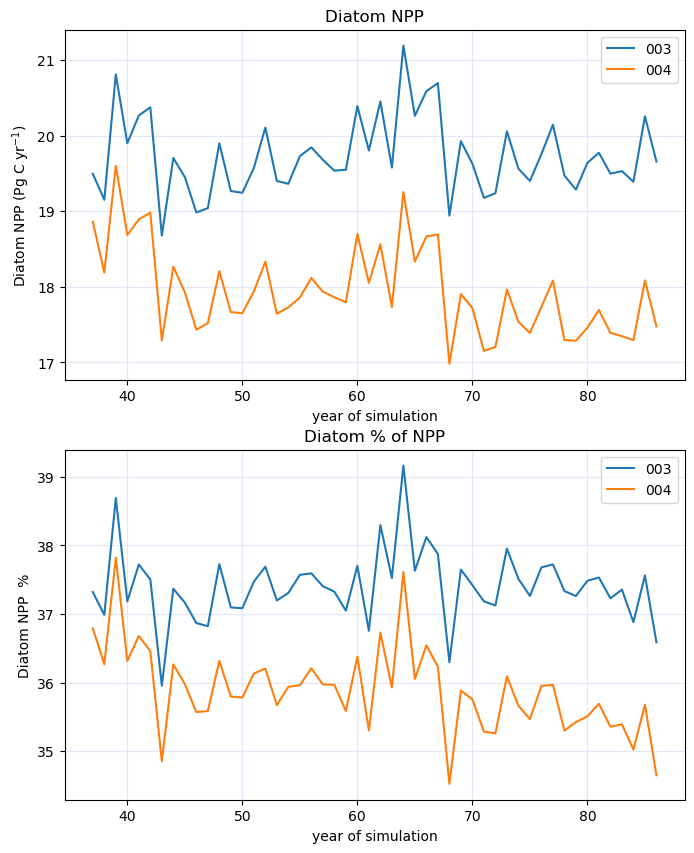

In [19]:
fig = plt.figure(figsize=(8,10))

#################
ax = fig.add_subplot(2,1,1)
ax.set_title('Diatom NPP')

i = 0

for case_num in case_nums:
    years = np.arange(st_yr,st_yr+len(glb_ds_dict[case_num].time),1)
    ax.plot(years,glb_ds_dict[case_num]['photoC_diat_zint'],label=short_names[i])
    i = i + 1


# ##################### mark where I tuned 
# var='photoC_diat_zint'
# year_tune=15
# ax.scatter(year_tune,(glb_ds_dict[case_num][var]).isel(time=year_tune-1),s=20,
#            marker='o',color='red',edgecolor='black', label='Tuning change')



ax.xaxis.grid(True, which='major',color='lavender')
ax.yaxis.grid(False, which='major',color='lavender');

ax.legend()

ax.set(ylabel='Diatom NPP (Pg C yr$^{-1}$)',xlabel='year of simulation');

##################
ax = fig.add_subplot(2,1,2)
ax.set_title('Diatom % of NPP')

i = 0

for case_num in case_nums:
    yyears = np.arange(st_yr,st_yr+len(glb_ds_dict[case_num].time),1)
    ax.plot(years,glb_ds_dict[case_num]['diatNPPpercent'],label=short_names[i])
    i = i + 1


# ##################### mark where I tuned 
# var='diatNPPpercent'
# year_tune=15
# ax.scatter(year_tune,(glb_ds_dict[case_num][var]).isel(time=year_tune-1),s=20,
#            marker='o',color='red',edgecolor='black', label='Tuning change')



ax.xaxis.grid(True, which='major',color='lavender')
ax.yaxis.grid(False, which='major',color='lavender');

ax.legend()


ax.set(ylabel='Diatom NPP  %',xlabel='year of simulation');